# Runs Test

(This notebook documents my practice of time series methods. While I have taken care going through the code, there may be errors or inefficiencies. This is the nature of learning, and I will be sure to keep updating this notebook as my understanding develops)

Code for Econometrics Project on the Weak form EMH. Using the Wald Walfowitz Runs test to test IID assumption. Tested with true IID and AR data. The runs test analyses the number of "runs" in a series. Let 1 denote +ve return in a period and 0 denote -ve return. A "run" is a sequence of 1s or 0s: (1, 1, 1, 1, 0, 1). In the previous example, the four 1s forms a run. If our data is truly IID, we expect to see fewer runs.

In [1]:
import numpy as np
from statsmodels.sandbox.stats.runs import runstest_1samp
import pandas as pd


def iid_normal(T):
    return np.random.normal(0, 1, T)

n = 1000
T = 10000

sequences = []
for i in range(n):
    r = iid_normal(T)
    sequences.append(r)
    
data = np.array(sequences).T
df = pd.DataFrame(data)

sig_level = []
for col in df.columns: 
   df[col] = np.where(df[col] >= 0, 1, 0)
   z_stat, p_val = runstest_1samp(df[col])
   if p_val < 0.05:
       sig_level.append(1)
   else:
       sig_level.append(0)

print((sum(sig_level))/n)



0.056


1,000 sequences of length 10,000. Runs test on each sequence, rough type 1 error rate of 5%.

In [1]:
import numpy as np
import pandas as pd
from statsmodels.sandbox.stats.runs import runstest_1samp

n = 1000
T = 10000
rho = 0.9

noise = np.random.normal(0, 1, (T, n))

X = np.zeros((T, n))

for t in range(1, T):
    X[t, :] = rho * X[t - 1, :] + noise[t, :] 

df = pd.DataFrame(X) 

sig_level = []
for col in df.columns:
    df[col] = np.where(df[col] >= 0, 1, 0)
    z_stat, p_val = runstest_1samp(df[col])
    if p_val < 0.05:
       sig_level.append(1)
    else:
       sig_level.append(0)

print((sum(sig_level))/n)

1.0


It seems when we generate our autoregressive data, Runs Test good at identifying autocorrelation.

C:\Users\danie\AppData\Local\Temp\ipykernel_15764\1470762283.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab10')


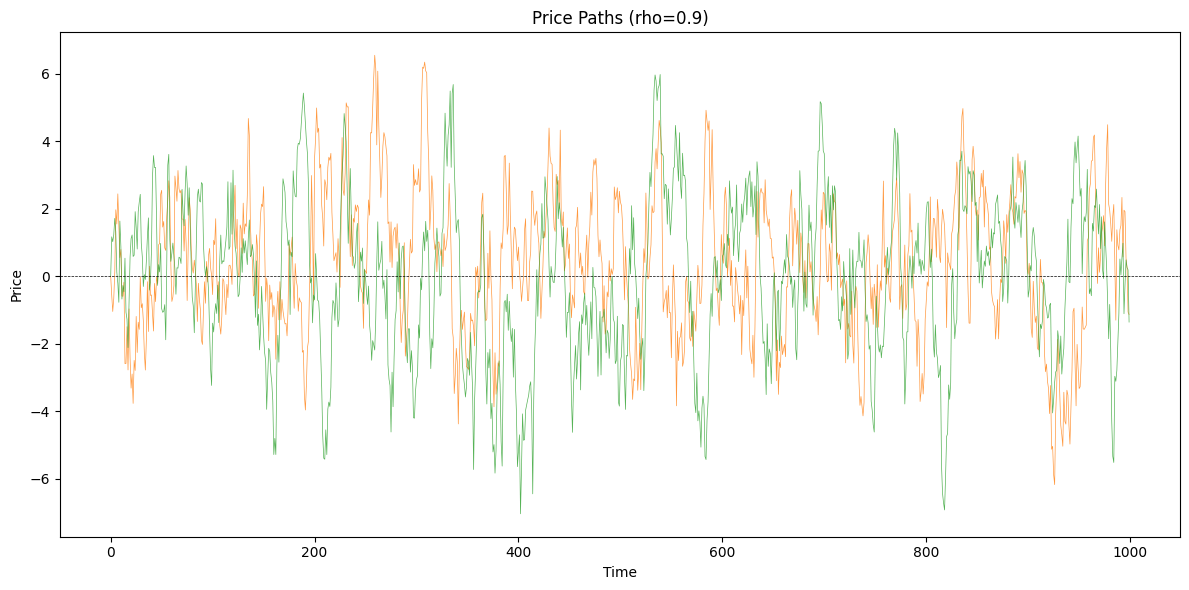

In [2]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

plt.figure(figsize=(12, 6))
cmap = cm.get_cmap('tab10')
for i in range(1, 3):
    plt.plot(X[:1000, i], alpha=0.8, linewidth=0.5, color = cmap(i % 10) )
plt.xlabel('Time')
plt.ylabel('Price')
plt.axhline(0, color='black', linestyle='--', linewidth=0.5)
plt.title(f'Price Paths (rho={rho})')
plt.tight_layout()
plt.show()